(04-22-risk-management)=

# VaR, RiskMetrics en LTCM

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1994–1998, van de publicatie van RiskMetrics tot de redding van
Long-Term Capital Management, met een nasleep tot de Basel-regels van 2016.

**Wat we al weten.** [ARCH, GARCH en realized volatility](#04-21-volatiliteit)
maakten van het tweede moment iets wat je van dag tot dag kunt voorspellen:
volatiliteit clustert, en een schatting uit de afgelopen weken zegt veel over
morgen. Dat is motief 1 in zijn nuttigste vorm. Uit [momentum crashes](#04-19-momentum)
weten we ook dat een strategie met een mooie Sharpe-ratio in drie maanden driekwart
van haar waarde kan verliezen, en dat die crashes zich aankondigen in de volatiliteit.

**Welke vraag staat open.** Kan een bank of een fonds met een voorspelbaar tweede
moment zijn kans op grote verliezen meten en begrenzen, en waarom was dat in 1998
niet genoeg?
```

## Overzicht

In oktober 1994 publiceerde J.P. Morgan RiskMetrics: een methode en een gratis
dataset van volatiliteiten en correlaties waarmee elke handelaar de *Value-at-Risk*
(VaR: het verlies dat met een gegeven kans, bijvoorbeeld 99%, over een gegeven
horizon niet wordt overschreden) van zijn portefeuille kon uitrekenen. De vierde
editie van het *Technical Document* uit december 1996 {cite}`JPMorganReuters1996`
werd het naslagwerk van een nieuw beroep, naast het leerboek van Philippe Jorion
{cite}`Jorion2006`. Al in januari 1996, nog vóór die vierde editie, maakte het Bazelse
Comité VaR tot grondslag van het kapitaal dat banken tegen marktrisico moeten aanhouden
{cite}`BCBS1996a`, met een regel om de modellen achteraf te toetsen {cite}`BCBS1996b`. Santa-Clara vat het samen: "Out of the crash came a discipline the
field had not had before: risk management as a function, with its own numbers, staff
and regulators" {cite}`SantaClara2026`.

Epistemisch is VaR geen theorie over prijzen maar een meetinstrument. Een backtest
toetst geen evenwicht, alleen of een voorspelling van een kwantiel klopt. Daarmee past
dit hoofdstuk in motief 3: de discipline verschuift van modellen die iets verklaren
naar getallen die iets moeten voorspellen. De statistiek van die toetsen komt van
{cite:t}`Kupiec1995` en {cite:t}`Christoffersen1998`; de theorie van wat een goede
risicomaat is, van {cite:t}`ArtznerDelbaenEberHeath1999`. Hun conclusie dat VaR
diversificatie kan bestraffen, leidde twintig jaar later tot de overstap op *Expected
Shortfall* (het gemiddelde verlies voorbij het kwantiel) in de regels van 2016
{cite}`BCBS2016`.

In september 1998 ging een fonds bijna failliet dat alles had wat de nieuwe discipline
voorschreef. Long-Term Capital Management (LTCM) had Robert Merton en Myron Scholes onder
zijn partners, een jaar na hun Nobelprijs {cite}`Lowenstein2000`, en risicomodellen die
zijn verliezen onmogelijk noemden. Santa-Clara's les nummer tien: "Leverage plus mark-to-market plus a deadline is
the recipe for ruin" {cite}`SantaClara2026`. We leiden VaR, Expected Shortfall en de
backtests af, laten zien hoe weinig een backtest van 250 dagen kan zien, en bouwen een
eenvoudig model van een gehefboomde arbitrageur waarin een positieve verwachte opbrengst
en een hoge kans op ruïne naast elkaar bestaan. Aan het eind backtesten we vier VaR-modellen
op de Amerikaanse aandelenmarkt van 1990 tot 2026, met de verkeerslichten van Bazel, en
bekijken we hoe credit spreads in augustus tot oktober 1998 uiteenliepen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy import stats
from scipy.special import xlogy

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een grote bank heeft honderden handelsposities in tientallen markten. De directie wil
aan het eind van de dag één getal: hoeveel kunnen we morgen verliezen? VaR geeft dat
getal als een kwantiel. "De 99%-VaR is 40 miljoen" betekent dat het verlies op één dag
op de honderd groter mag zijn dan 40 miljoen. Het getal is aantrekkelijk om drie
redenen. Het telt posities in obligaties, valuta en aandelen bij elkaar op in één munt.
Het beloont diversificatie, omdat posities die niet samen bewegen elkaar deels
opheffen. En het vraagt alleen een schatting van de spreiding van morgen, niet van het
verwachte rendement: op één dag is het gemiddelde verwaarloosbaar klein ten opzichte
van de standaarddeviatie. Precies het moment dat slecht meetbaar is, doet er dus niet
toe, en het moment dat goed meetbaar is, wel.

Het getal heeft ook drie zwakke plekken. De eerste noemt Santa-Clara: "the number was
dangerous, because it said nothing about the days that exceeded it, and the days that
exceed it are the only ones that matter" {cite}`SantaClara2026`. Een VaR van 40 miljoen
zegt niet of het verlies op die ene slechte dag 41 of 400 miljoen is. De tweede is dat
een kwantiel van 1% slecht te controleren is. In een jaar van 250 handelsdagen verwacht
je twee à drie overschrijdingen; vijf kunnen pech zijn, en een model dat in werkelijkheid
maar 98% dekt, geeft ook vaak niet meer dan vijf. De derde is minder zichtbaar: VaR kan
een gespreide portefeuille riskanter noemen dan de som van haar delen. Twee obligaties
met elk een kleine kans op wanbetaling hebben afzonderlijk een VaR van nul, samen niet.

Dan LTCM. Het fonds kocht effecten die net iets goedkoper waren dan vrijwel identieke
andere en verkocht die duurdere, voor het grootste deel in obligatiemarkten: ongeveer
80% van de balansposities waren staatsobligaties van de G-7-landen. Zo'n
*convergence trade* (een positie die winst maakt als twee prijzen naar elkaar toe
bewegen) verdient een fractie van een procent per euro. Om daar een fatsoenlijk
rendement van te maken, moet je lenen. Op 31 augustus 1998 stond er meer dan 125
miljard dollar op de balans, tegen een eigen vermogen van 4,8 miljard aan het begin van
het jaar: een hefboom van meer dan 25 {cite}`PresidentsWorkingGroup1999`, met daarnaast
derivatencontracten met een nominale waarde van meer dan een biljoen dollar
{cite}`Edwards1999`. Zolang de spreads versmallen,
gaat dat goed. Verbreden ze, dan ziet het fonds dat elke dag in zijn waardering
(*mark-to-market*), vragen tegenpartijen onmiddellijk extra onderpand, en moet het fonds
verkopen voordat de convergentie heeft plaatsgevonden. Dat is de deadline.

Het laatste element maakt van een verlies een ramp. Als het fonds groot is, of als veel
fondsen dezelfde positie hebben, drukt de gedwongen verkoop de prijs verder in de
verkeerde richting, en dat verlies leidt tot de volgende gedwongen verkoop. De
liquiditeit waarop het risicomodel rekende, verdwijnt precies wanneer het fonds haar
nodig heeft. Santa-Clara's les nummer negen: "Liquidity is priced, and it disappears
when you need it" {cite}`SantaClara2026`. Een Sharpe-ratio meet de verhouding van
rendement tot spreiding en is dezelfde bij elke hefboom; de kans om de periode te
overleven waarin het rendement binnenkomt, is dat niet.

## Toy-voorbeeld: twee posities, twee obligaties en een convergence trade

**(a) Parametrische VaR.** Een handelaar heeft 100 miljoen in aandeel A met een
dagvolatiliteit van 1,5% en 50 miljoen in aandeel B met 1,0%, met correlatie 0,4.
Verwachte dagrendementen zetten we op nul. De standaarddeviaties van de posities in
euro zijn $100 \times 0{,}015 = 1{,}5$ miljoen en $50 \times 0{,}010 = 0{,}5$ miljoen. De
variantie van de portefeuille is

$$
\sigma_p^2 = 1{,}5^2 + 0{,}5^2 + 2 \times 0{,}4 \times 1{,}5 \times 0{,}5
= 2{,}25 + 0{,}25 + 0{,}60 = 3{,}10,
$$

dus $\sigma_p = 1{,}7607$ miljoen. Met $z_{0{,}99} = \Phi^{-1}(0{,}99) = 2{,}3263$ is de
99%-VaR op één dag $2{,}3263 \times 1{,}7607 = 4{,}096$ miljoen. De VaR's van de posities
afzonderlijk zijn $3{,}490$ en $1{,}163$, samen $4{,}653$ miljoen: de spreiding over twee
aandelen levert $0{,}557$ miljoen minder VaR op. Wie de tien dagen van Bazel met de
wortel-uit-de-tijdregel wil halen, vermenigvuldigt met $\sqrt{10}$ en krijgt $12{,}95$
miljoen.

**(b) Twee obligaties.** Een obligatie levert over het jaar 2 op als de uitgever niet
failleert en verliest 100 als hij wel failleert, met kans 4%. Het verlies $L$ is dus $-2$
met kans 0,96 en 100 met kans 0,04. Bij een betrouwbaarheid van 95% is de VaR het
kleinste verlies $\ell$ waarvoor $P(L > \ell) \le 5\%$. Omdat $P(L > -2) = 4\%$, is de VaR
van één obligatie $-2$: geen verlies. Twee onafhankelijke obligaties hebben verlies $-4$
met kans $0{,}96^2 = 0{,}9216$, 98 met kans $2 \times 0{,}96 \times 0{,}04 = 0{,}0768$ en
200 met kans $0{,}0016$. Nu is $P(L > -4) = 7{,}84\% > 5\%$, en de VaR springt naar 98. De
VaR van de som (98) is veel groter dan de som van de VaR's ($-4$). Spreiden over twee
debiteuren lijkt volgens VaR het risico te verhogen.

De Expected Shortfall op 95% middelt over de slechtste 5% van de uitkomsten. Voor één
obligatie is dat 4% met verlies 100 en 1% met $-2$:
$(0{,}04 \times 100 + 0{,}01 \times (-2))/0{,}05 = 79{,}6$. Voor twee obligaties is het
$(0{,}0016 \times 200 + 0{,}0484 \times 98)/0{,}05 = 101{,}26$, kleiner dan
$2 \times 79{,}6 = 159{,}2$. Expected Shortfall ziet het voordeel van spreiden wel.

**(c) Een convergence trade met hefboom.** Een fonds heeft eigen vermogen $E_0 = 100$ en
neemt een positie $X = L E_0$ in een spread met *spread duration* $D = 5$ (de positie
verliest $D$ maal de spreadverbreding, in procenten van de omvang). Een tegenpartij eist
een *haircut* (het deel van de positie dat met eigen geld gefinancierd moet zijn) van
$h = 2\%$, dus het eigen vermogen moet minstens $hX$ zijn. Bij $L = 25$ is $X = 2500$ en
kost elk basispunt verbreding $2500 \times 5 \times 0{,}0001 = 1{,}25$. De margin call
komt als het vermogen onder $0{,}02 \times 2500 = 50$ zakt, dus na een verlies van 50 of
een verbreding van $50/1{,}25 = 40$ basispunten. Het vermogen is op bij 80 basispunten.
Bij $L = 10$ kost een basispunt $0{,}5$, komt de margin call bij een vermogen van 20, dus
na $80/0{,}5 = 160$ basispunten, en is het vermogen op na 200.

Nu met prijsdruk. Stel dat elke verkoop van 100 aan positie de spread met 1 basispunt
verbreedt. Het fonds met $L = 25$ staat precies op de grens ($E = 50$, $X = 2500$) en de
spread verbreedt nog 10 basispunten. Het directe verlies is $12{,}5$, dus $E = 37{,}5$ en
de positie mag nog maar $37{,}5/0{,}02 = 1875$ zijn. Het fonds verkoopt 625; de spread
verbreedt $6{,}25$ basispunten; op de resterende 1875 kost dat
$1875 \times 5 \times 0{,}000625 = 5{,}86$. Nu is $E = 31{,}64$, mag de positie nog 1582
zijn, wordt 293 verkocht, verbreedt de spread nog $2{,}93$ basispunten en kost dat
$2{,}32$. De rondes worden kleiner en het proces convergeert, zoals de code hieronder
laat zien, naar een totaal verlies van 22,0: bijna het dubbele van de 12,5 die de
exogene schok zelf kostte. De spread is dan niet 10 maar 21,0 basispunten verbreed, en
de helft daarvan heeft het fonds zelf veroorzaakt.

In [2]:
# (a) parametric VaR of two positions
w = np.array([100.0, 50.0])
sig = np.array([0.015, 0.010])
rho = 0.4
cov = np.array([[sig[0]**2, rho * sig[0] * sig[1]], [rho * sig[0] * sig[1], sig[1]**2]])
z99 = stats.norm.ppf(0.99)
sd_p = np.sqrt(w @ cov @ w)
var_p, var_each = z99 * sd_p, z99 * w * sig


def var_es_discrete(losses, probs, alpha):
    """VaR and Expected Shortfall at level alpha of a discrete loss distribution."""
    order = np.argsort(losses)
    loss, p = np.asarray(losses, float)[order], np.asarray(probs, float)[order]
    cdf = np.cumsum(p)
    var = loss[np.searchsorted(cdf, alpha - 1e-12)]
    tail_mass = np.clip(cdf - np.maximum(cdf - p, alpha), 0.0, None)
    return var, (tail_mass * loss).sum() / (1 - alpha)


# (b) two bonds with 4% default probability
var_1, es_1 = var_es_discrete([-2.0, 100.0], [0.96, 0.04], 0.95)
var_2, es_2 = var_es_discrete([-4.0, 98.0, 200.0], [0.96**2, 2 * 0.96 * 0.04, 0.04**2], 0.95)

# (c) levered convergence trade: thresholds and a fire-sale spiral
E0, D, H, KAPPA = 100.0, 5.0, 0.02, 1e-6       # kappa: spread widening per unit sold
thresholds = {L: (1e4 * (1 - H * L) / (L * D), 1e4 / (L * D)) for L in (10, 25)}
X, E = 2500.0, 50.0 - 2500.0 * D * 0.0010       # at the margin limit, then a 10bp shock
spread_move, rounds = 10.0, []
while True:
    X_new = max(E, 0.0) / H
    sold = X - X_new
    if sold < 1e-9:
        break
    widening = KAPPA * sold
    E -= X_new * D * widening
    spread_move += 1e4 * widening
    rounds.append((sold, 1e4 * widening, E))
    X = X_new

print(f"(a) sigma_p = {sd_p:.4f}, VaR_99 = {var_p:.3f}, losse VaR's = {var_each.round(3)}, "
      f"som = {var_each.sum():.3f}, 10 dagen = {var_p * np.sqrt(10):.2f}")
print(f"(b) één obligatie: VaR = {var_1:.1f}, ES = {es_1:.2f}; twee: VaR = {var_2:.1f}, ES = {es_2:.2f}")
print(f"(c) drempels (margin call, ruïne) in bp: {thresholds}")
print("    eerste twee rondes (verkocht, bp, E):", [tuple(np.round(x, 2)) for x in rounds[:2]])
print(f"    na convergentie: E = {E:.2f}, verlies = {50 - E:.2f}, spreadverbreding = {spread_move:.1f} bp")
print("code == handberekening:", np.allclose(
    [sd_p, var_p, var_each.sum(), var_1, es_1, var_2, es_2, 50 - E, spread_move],
    [1.7607, 4.096, 4.653, -2.0, 79.6, 98.0, 101.26, 22.0, 21.0], atol=0.051))

(a) sigma_p = 1.7607, VaR_99 = 4.096, losse VaR's = [3.49  1.163], som = 4.653, 10 dagen = 12.95
(b) één obligatie: VaR = -2.0, ES = 79.60; twee: VaR = 98.0, ES = 101.26
(c) drempels (margin call, ruïne) in bp: {10: (160.0, 200.0), 25: (40.0, 80.0)}
    eerste twee rondes (verkocht, bp, E): [(np.float64(625.0), np.float64(6.25), np.float64(31.64)), (np.float64(292.97), np.float64(2.93), np.float64(29.32))]
    na convergentie: E = 28.01, verlies = 21.99, spreadverbreding = 21.0 bp
code == handberekening: True


## Theorie

### VaR en Expected Shortfall

Laat $W_t$ de waarde van een portefeuille op $t$ zijn en $L_{t+1} = -(W_{t+1} - W_t)$ het
verlies over de horizon, bekend op $t+1$. Alle kansen zijn conditioneel op de informatie
op $t$; we schrijven $P_t$.

:::{prf:definition} Value-at-Risk
:label: def-risk-management-var

De Value-at-Risk op betrouwbaarheid $\alpha \in (0,1)$ is het $\alpha$-kwantiel van het
verlies:

```{math}
:label: eq-risk-management-var
\mathrm{VaR}_{\alpha,t} = \inf\left\{\ell \in \mathbb{R} : P_t\!\left(L_{t+1} > \ell\right) \le 1-\alpha\right\}.
```
:::

:::{prf:definition} Expected Shortfall
:label: def-risk-management-es

De Expected Shortfall op betrouwbaarheid $\alpha$ is het gemiddelde van de VaR's boven
$\alpha$:

```{math}
:label: eq-risk-management-es
\mathrm{ES}_{\alpha,t} = \frac{1}{1-\alpha}\int_\alpha^1 \mathrm{VaR}_{u,t}\,\mathrm{d}u .
```

Heeft $L_{t+1}$ een continue verdeling, dan is
$\mathrm{ES}_{\alpha,t} = \E_t\!\left[L_{t+1} \mid L_{t+1} \ge \mathrm{VaR}_{\alpha,t}\right]$.
:::

De integraalvorm is de goede definitie omdat ze ook voor verdelingen met atomen werkt,
zoals die van de obligaties in het toy-voorbeeld. Daar is de staart boven 95% voor 4
procentpunt het atoom op 100 en voor 1 procentpunt het atoom op $-2$.

*Waarom zou dit waar zijn?* Als het verlies normaal verdeeld is, zijn alle kwantielen
gelijk aan het gemiddelde plus een vast aantal standaarddeviaties. Voor de VaR is dat
aantal het kwantiel van de standaardnormale verdeling; voor de ES het gemiddelde van de
standaardnormale verdeling boven dat kwantiel, en dat gemiddelde ligt verder in de staart.

:::{prf:proposition} VaR en ES onder normaliteit
:label: prop-risk-management-normaal

Is $L_{t+1} \sim \mathcal{N}(\mu_L, \sigma^2)$ gegeven de informatie op $t$, dan geldt

```{math}
:label: eq-risk-management-normaal
\mathrm{VaR}_{\alpha} = \mu_L + \sigma z_\alpha,
\qquad
\mathrm{ES}_{\alpha} = \mu_L + \sigma \frac{\varphi(z_\alpha)}{1-\alpha},
\qquad z_\alpha = \Phi^{-1}(\alpha),
```

met $\varphi$ en $\Phi$ de dichtheid en verdelingsfunctie van de standaardnormale
verdeling.
:::

:::{prf:proof}
Schrijf $L = \mu_L + \sigma Z$. Het $\alpha$-kwantiel van $L$ is $\mu_L + \sigma z_\alpha$
omdat een stijgende affiene transformatie kwantielen behoudt. Voor de ES is
$\E[Z \mid Z \ge z_\alpha] = \frac{1}{1-\alpha}\int_{z_\alpha}^\infty z\varphi(z)\,\mathrm{d}z$,
en omdat $\varphi'(z) = -z\varphi(z)$ is die integraal $\varphi(z_\alpha)$. $\square$
:::

Voor $\alpha = 0{,}99$ is $z_\alpha = 2{,}326$ en $\varphi(z_\alpha)/(1-\alpha) = 2{,}665$.
Voor $\alpha = 0{,}975$ is $z_\alpha = 1{,}960$ en de ES-factor $2{,}338$. Onder
normaliteit is de ES op 97,5% dus bijna precies de VaR op 99%. Dat is geen toeval: toen
het Bazelse Comité in 2016 van VaR op 99% overstapte op ES, koos het 97,5% ("a 97.5th
percentile, one-tailed confidence level", paragraaf 181(b) van {cite}`BCBS2016`), zodat
het kapitaal onder normale verdelingen gelijk bleef en alleen dikke staarten meer kosten.

### Drie manieren om het kwantiel te schatten

Voor een portefeuille met gewichten $\mathbf{w}$ in euro en rendementen met
covariantiematrix $\boldsymbol{\Sigma}_t$ is de **parametrische** of
variantie-covariantie-VaR, met verwachte rendementen op nul,

```{math}
:label: eq-risk-management-parametrisch
\mathrm{VaR}_{\alpha,t} = z_\alpha \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_t \mathbf{w}} .
```

Dit is wat RiskMetrics deed: de gemiddelde dagrendementen worden op nul gezet ("In
RiskMetrics, we assume that the mean value of daily returns is zero", p. 92–93 van
{cite}`JPMorganReuters1996`), en alle werk zit in $\boldsymbol{\Sigma}_t$. Het
Technical Document werkte met 95% en $1{,}65\,\sigma$; Bazel eiste 99%.

**Historische simulatie** gebruikt geen verdeling: neem de huidige posities, pas de
rendementen van de afgelopen $K$ dagen erop toe, en lees het empirische kwantiel af. Dat
vangt dikke staarten en niet-lineaire posities, maar reageert traag. Een crash telt
$K$ dagen even zwaar mee en valt er dan in één keer uit. Na een rustig jaar voorspelt
het een rustig jaar.

**Filtered historical simulation** combineert beide
{cite}`HullWhite1998,BaroneAdesiGiannopoulosVosper1999`. Deel elk historisch rendement
door de volatiliteit die toen gold, $\hat\varepsilon_s = r_s/\hat\sigma_s$, en vermenigvuldig
de gestandaardiseerde residuen met de volatiliteit van vandaag:
$\mathrm{VaR}_{\alpha,t} = -\hat\sigma_{t+1}\,\hat q_{1-\alpha}(\hat\varepsilon)$. De vorm
van de staart komt uit de data, het niveau uit een volatiliteitsmodel.

### EWMA als speciaal geval van GARCH

*Waarom zou dit waar zijn?* RiskMetrics wilde één volatiliteitsschatter voor 480 reeksen
die snel reageert op nieuwe schokken en zonder schatting van parameters per reeks werkt.
Een gewogen gemiddelde van gekwadrateerde rendementen met exponentieel dalende gewichten
doet dat. Het blijkt een GARCH-model te zijn waarin de schokken nooit uitdoven.

De *exponentially weighted moving average* (EWMA) is

```{math}
:label: eq-risk-management-ewma
\sigma_{t+1}^2 = \lambda\,\sigma_t^2 + (1-\lambda)\,r_t^2
= (1-\lambda)\sum_{j=0}^{\infty} \lambda^j r_{t-j}^2 .
```

RiskMetrics koos de *decay factor* $\lambda$ die over alle reeksen de gemiddelde
kwadratische voorspelfout van de variantie minimaliseert, en vond "that the decay factor
for the daily data set is 0.94, and the decay factor for the monthly data set is 0.97"
(§5.3.2.2, p. 100 van {cite}`JPMorganReuters1996`). De tabel 5.8 daarboven laat zien dat
het optimum per reeks uiteenliep van 0,835 tot 0,995; 0,94 is een compromis. Het
gewicht van waarneming $j$ is $(1-\lambda)\lambda^j$; wie de dagen weglaat waarvan het
cumulatieve gewicht onder 1% ligt, gebruikt $K = \ln 0{,}01/\ln\lambda$ dagen, bij
$\lambda = 0{,}94$ ongeveer 74 (tabel 5.7).

Vergelijk met GARCH(1,1) uit [de vorige lecture](#04-21-volatiliteit)
{cite}`Engle1982,Bollerslev1986`:

```{math}
:label: eq-risk-management-garch
\sigma_{t+1}^2 = \omega + a\, r_t^2 + b\,\sigma_t^2 .
```

EWMA is het geval $\omega = 0$, $a = 1-\lambda$, $b = \lambda$. Dan is $a + b = 1$: het
*integrated* GARCH-model (IGARCH) van {cite:t}`EngleBollerslev1986`, waarin de variantie
geen eindig onvoorwaardelijk niveau heeft. Wij schrijven $a, b$ in plaats van de
gebruikelijke $\alpha, \beta$, omdat $\alpha$ hier de betrouwbaarheid is en $\beta$ in deze
reeks de bèta.

:::{prf:proposition} Variantie over $k$ dagen
:label: prop-risk-management-horizon

Laat de rendementen conditioneel ongecorreleerd zijn met gemiddelde nul. Onder
GARCH(1,1) met $a + b < 1$ en $\bar\sigma^2 = \omega/(1-a-b)$ geldt

```{math}
:label: eq-risk-management-horizon
\Var_t\!\left(\sum_{j=1}^{k} r_{t+j}\right)
= k\,\bar\sigma^2 + \frac{1-(a+b)^k}{1-(a+b)}\left(\sigma_{t+1}^2 - \bar\sigma^2\right).
```

Onder EWMA ($\omega = 0$, $a+b = 1$) is de variantie over $k$ dagen $k\,\sigma_{t+1}^2$, en
de wortel-uit-de-tijdregel $\mathrm{VaR}^{(k)} = \sqrt{k}\,\mathrm{VaR}^{(1)}$ is voor de
variantie exact.
:::

:::{prf:proof}
Omdat de rendementen conditioneel ongecorreleerd zijn, is de variantie van de som de som
van $\E_t[\sigma_{t+j}^2]$. Neem in [](#eq-risk-management-garch) de verwachting op $t$
en gebruik $\E_t[r_{t+j}^2] = \E_t[\sigma_{t+j}^2]$:
$\E_t[\sigma_{t+j+1}^2] = \omega + (a+b)\E_t[\sigma_{t+j}^2]$. Dat is een lineaire
differentievergelijking met oplossing
$\E_t[\sigma_{t+j}^2] = \bar\sigma^2 + (a+b)^{j-1}(\sigma_{t+1}^2 - \bar\sigma^2)$. Tel op
over $j = 1, \dots, k$ met de meetkundige reeks. Bij $a + b = 1$ en $\omega = 0$ is elke
term $\sigma_{t+1}^2$. $\square$
:::

De wortel-uit-de-tijdregel, die Bazel toestond ("scaled up to ten days by the square root
of time", B.4(c) van {cite}`BCBS1996a`), faalt dus om drie redenen. Onder GARCH trekt de
volatiliteit terug naar haar gemiddelde: in een crisis overschat $\sqrt{k}$ de variantie
over lange horizon, in rustige tijden onderschat hij haar. Daarnaast verandert de vorm
van de verdeling met de horizon; een kwantiel van dikstaartige dagrendementen maal
$\sqrt{k}$ is niet het kwantiel van de som. En de belangrijkste reden is economisch: de
regel veronderstelt dat de positie tien dagen stil blijft staan en daarna tegen de
geldende prijs kan worden gesloten. Wie in een crisis moet verkopen, kan dat niet. De
regels van 2016 vervangen de tien dagen daarom door *liquidity horizons* (de tijd die het
kost om een positie zonder grote prijsdruk af te bouwen) van 10 tot 120 dagen per
risicocategorie, paragraaf 181(c) en (k) van {cite}`BCBS2016`.

In [3]:
A_GARCH, B_GARCH = 0.08, 0.91   # daily GARCH(1,1), persistence 0.99


def horizon_ratio(state, k, a=A_GARCH, b=B_GARCH):
    """sqrt of true k-day variance over k * one-day variance, with sigma_{t+1}^2 = state * sigma_bar^2."""
    persistence = a + b
    true = k + (1 - persistence**k) / (1 - persistence) * (state - 1)
    return np.sqrt(true / (k * state))


states = [0.25, 1.0, 4.0, 16.0]
pd.DataFrame({f"k = {k}": [horizon_ratio(s, k) for s in states] for k in (10, 60, 250)},
             index=pd.Index(states, name="sigma_{t+1}^2 / sigma_bar^2")).round(3)

,k = 10,k = 60,k = 250
sigma_{t+1}^2 / sigma_bar^2,,,
0.25,1.064,1.317,1.702
1.00,1.000,1.000,1.000
4.00,0.983,0.903,0.725
16.00,0.979,0.878,0.638


Bij een persistentie van 0,99 is de fout over tien dagen klein: de werkelijke
volatiliteit is 6% hoger dan $\sqrt{10}$ voorspelt als de volatiliteit op de helft van
haar gemiddelde staat, en 2% lager als ze op het viervoudige staat. Over een jaar is het
verschil een factor twee. Voor de horizon van Bazel is de mean reversion dus niet het
probleem; de staart en de liquiditeit zijn het.

### Backtesting: Kupiec en Christoffersen

*Waarom zou dit waar zijn?* Als een VaR-model op elke dag het juiste conditionele
kwantiel geeft, is de kans op een overschrijding elke dag precies $p = 1-\alpha$, wat er
ook eerder is gebeurd. De reeks overschrijdingen is dan een reeks onafhankelijke
muntworpen met kans $p$. Een goed model moet dus twee dingen halen: het juiste aantal
overschrijdingen, en geen patroon in wanneer ze komen.

Definieer de *hit sequence* $I_{t+1} = \mathbb{1}\{L_{t+1} > \mathrm{VaR}_{\alpha,t}\}$.

:::{prf:proposition} Hits zijn Bernoulli
:label: prop-risk-management-hits

Is $\mathrm{VaR}_{\alpha,t}$ het ware conditionele $\alpha$-kwantiel en heeft $L_{t+1}$
een continue conditionele verdeling, dan is $\{I_{t+1}\}$ een reeks onafhankelijke
Bernoulli-variabelen met kans $p = 1-\alpha$.
:::

:::{prf:proof}
Per definitie is $P_t(I_{t+1} = 1) = 1-\alpha$ voor elke informatieverzameling op $t$, en
$I_s$ voor $s \le t$ zit in die informatie. Dus $P(I_{t+1} = 1 \mid I_1, \dots, I_t) = p$.
Een binaire reeks waarvan elke conditionele kans op 1 gelijk is aan dezelfde constante,
is onafhankelijk en identiek verdeeld: de gezamenlijke kans van elk patroon is het product
van de marginale kansen. $\square$
:::

{cite:t}`Kupiec1995` toetste het eerste deel. Met $x$ overschrijdingen in $T$ dagen en
$\hat\pi = x/T$ is de *proportion-of-failures*-toets de likelihood-ratio van
$H_0: \pi = p$:

```{math}
:label: eq-risk-management-kupiec
\mathrm{LR}_{\mathrm{pof}} = -2\ln\frac{(1-p)^{T-x}p^{x}}{(1-\hat\pi)^{T-x}\hat\pi^{x}}
\;\overset{a}{\sim}\; \chi^2_1 .
```

{cite:t}`Christoffersen1998` voegde het tweede deel toe. Laat $n_{ij}$ het aantal dagen
zijn waarop $I_t = i$ werd gevolgd door $I_{t+1} = j$, en
$\hat\pi_{01} = n_{01}/(n_{00}+n_{01})$, $\hat\pi_{11} = n_{11}/(n_{10}+n_{11})$,
$\hat\pi = (n_{01}+n_{11})/(n_{00}+n_{01}+n_{10}+n_{11})$. Onder een eersteorde
Markov-keten als alternatief is de onafhankelijkheidstoets

```{math}
:label: eq-risk-management-christoffersen
\mathrm{LR}_{\mathrm{ind}} = -2\ln\frac{(1-\hat\pi)^{n_{00}+n_{10}}\hat\pi^{n_{01}+n_{11}}}
{(1-\hat\pi_{01})^{n_{00}}\hat\pi_{01}^{n_{01}}(1-\hat\pi_{11})^{n_{10}}\hat\pi_{11}^{n_{11}}}
\;\overset{a}{\sim}\; \chi^2_1,
\qquad
\mathrm{LR}_{\mathrm{cc}} = \mathrm{LR}_{\mathrm{pof}} + \mathrm{LR}_{\mathrm{ind}}
\;\overset{a}{\sim}\; \chi^2_2 .
```

$\mathrm{LR}_{\mathrm{cc}}$ is de toets op *conditional coverage*: het juiste aantal én
geen clustering. Een statisch model dat in rustige jaren te weinig en in crises te veel
overschrijdingen geeft, kan over de hele steekproef het juiste aantal halen en toch
falen, omdat een overschrijding gisteren de kans op een overschrijding vandaag verhoogt.

Het Bazelse kader van januari 1996 gebruikt alleen het aantal. Het telt de
overschrijdingen van de 99%-VaR op één dag over de laatste 250 handelsdagen. Het
verkeerslicht staat op groen bij 0 tot 4, op geel bij 5 tot 9 en op rood bij 10 of meer.
De geelgrens is het eerste aantal waarbij de binomiale kans op zoveel of minder
overschrijdingen onder een juist model minstens 95% is; de roodgrens waar die kans
minstens 99,99% is. In het gele gebied stijgt de vermenigvuldigingsfactor van het
kapitaal (minimaal 3) met 0,40 tot 0,85, in het rode met 1 {cite}`BCBS1996b`. Het Comité
wist wat het deed: "tests of this type are limited in their power to distinguish an
accurate model from an inaccurate model" (p. 5).

In [4]:
def kupiec_lr(hits, p=0.01):
    """Kupiec (1995) proportion-of-failures LR statistic; hits along the last axis."""
    # TODO: naar hap.stats
    hits = np.asarray(hits, float)
    T, x = hits.shape[-1], hits.sum(axis=-1)
    pi_hat = x / T
    return -2 * ((xlogy(T - x, 1 - p) + xlogy(x, p)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))


def christoffersen_lr(hits, p=0.01):
    """Christoffersen (1998) independence and conditional-coverage LR statistics."""
    # TODO: naar hap.stats
    hits = np.asarray(hits, float)
    h0, h1 = hits[..., :-1], hits[..., 1:]
    n00, n01 = ((1 - h0) * (1 - h1)).sum(-1), ((1 - h0) * h1).sum(-1)
    n10, n11 = (h0 * (1 - h1)).sum(-1), (h0 * h1).sum(-1)
    pi01, pi11 = n01 / np.maximum(n00 + n01, 1), n11 / np.maximum(n10 + n11, 1)
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    lr_ind = -2 * ((xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi))
                   - (xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)))
    return lr_ind, kupiec_lr(hits, p) + lr_ind


k = np.arange(11)
basel = pd.DataFrame({"overschrijdingen": k,
                      "P(X <= k), p = 1%": stats.binom.cdf(k, 250, 0.01),
                      "P(X >= k), p = 2%": stats.binom.sf(k - 1, 250, 0.02),
                      "LR_pof": kupiec_lr(np.array([np.r_[np.ones(i), np.zeros(250 - i)] for i in k]))})
basel["zone"] = pd.cut(basel["overschrijdingen"], [-1, 4, 9, 250], labels=["groen", "geel", "rood"])
basel.round(4)

,overschrijdingen,"P(X <= k), p = 1%","P(X >= k), p = 2%",LR_pof,zone
0,0,0.0811,1.0000,5.0252,groen
1,1,0.2858,0.9936,1.1765,groen
2,2,0.5432,0.9609,0.1084,groen
3,3,0.7581,0.8779,0.0949,groen
4,4,0.8922,0.7378,0.7691,groen
5,5,0.9588,0.5613,1.9568,geel
6,6,0.9863,0.3840,3.5554,geel
7,7,0.9960,0.2363,5.4970,geel
8,8,0.9989,0.1313,7.7336,geel
9,9,0.9997,0.0661,10.2290,geel


De cumulatieve kansen zijn tabel 2 van het Bazelse kader: 89,22% bij vier, 95,88% bij
vijf, 99,97% bij negen en 99,99% bij tien overschrijdingen. De derde kolom is het
probleem. Een model dat in werkelijkheid maar 98% dekt, geeft verwacht vijf
overschrijdingen per jaar, maar blijft met kans 44% in het groene gebied (de kans op
vijf of meer is 56%). Kupiec's toets verwerpt op 5% pas vanaf zeven overschrijdingen
($\mathrm{LR}_{\mathrm{pof}} = 5{,}5 > 3{,}84$).

Dit is motief 1 in de staart. Een kans van 1% geschat uit 250 dagen heeft een
standaardfout van $\sqrt{0{,}01 \times 0{,}99/250} = 0{,}63$ procentpunt: 63% van de kans
zelf. De staart van de verdeling is voor het gemiddelde wat het gemiddelde voor de
variantie is. Een VaR-model is dus niet op een jaar te beoordelen, en een model dat
tien jaar goed ging, kan evengoed te weinig dekken.

### Coherente risicomaten

*Waarom zou dit waar zijn?* Een risicomaat is een regel die zegt hoeveel kapitaal er
naast een positie moet staan. Vier eisen liggen voor de hand. Een positie die altijd
slechter uitpakt, heeft meer kapitaal nodig. Twee keer dezelfde positie heeft twee keer
zoveel nodig. Een euro contant geld erbij vermindert de eis met een euro. En twee
posities samen hebben niet meer nodig dan apart, want anders loont het om een bank op te
splitsen en is het kapitaal van het geheel niet te sturen door limieten per afdeling.

:::{prf:definition} Coherente risicomaat
:label: def-risk-management-coherent

Een afbeelding $\rho$ van verliezen naar $\mathbb{R}$ heet coherent
{cite}`ArtznerDelbaenEberHeath1999` als voor alle verliezen $L_1, L_2$, alle $c \ge 0$ en
alle $m \in \mathbb{R}$ geldt:

1. *monotoniteit*: $L_1 \le L_2$ bijna zeker impliceert $\rho(L_1) \le \rho(L_2)$;
2. *subadditiviteit*: $\rho(L_1 + L_2) \le \rho(L_1) + \rho(L_2)$;
3. *positieve homogeniteit*: $\rho(cL_1) = c\,\rho(L_1)$;
4. *translatie-invariantie*: $\rho(L_1 + m) = \rho(L_1) + m$.
:::

Artzner, Delbaen, Eber en Heath schreven de axioma's voor toekomstige nettowaarden met
een referentie-instrument; wij vertalen naar verliezen, wat de tekens omdraait.

:::{prf:theorem} VaR is niet coherent, ES wel
:label: thm-risk-management-coherentie

VaR voldoet aan 1, 3 en 4 maar niet in het algemeen aan 2. ES voldoet aan alle vier.
Hebben $(L_1, L_2)$ een gezamenlijk normale verdeling, dan is ook VaR voor
$\alpha \ge 1/2$ subadditief.
:::

:::{prf:proof}
:class: dropdown

*VaR.* Monotoniteit, homogeniteit en translatie-invariantie volgen omdat kwantielen
behouden blijven onder stijgende transformaties en affiene transformaties met positieve
helling. Het toy-voorbeeld (b) is een tegenvoorbeeld voor subadditiviteit:
$\mathrm{VaR}_{0{,}95}(L_1+L_2) = 98 > -4 = \mathrm{VaR}_{0{,}95}(L_1) + \mathrm{VaR}_{0{,}95}(L_2)$.

*ES.* Monotoniteit, homogeniteit en translatie-invariantie erft ES van VaR via
[](#eq-risk-management-es). Voor subadditiviteit gebruiken we een duale vorm
{cite}`AcerbiTasche2002`:

$$
\mathrm{ES}_\alpha(L) = \sup\left\{\E[L\,\xi] : 0 \le \xi \le \tfrac{1}{1-\alpha},\ \E[\xi] = 1\right\}.
$$

Het supremum wordt bereikt door $\xi$ zijn maximale waarde te geven op de slechtste
fractie $1-\alpha$ van de uitkomsten (met een fractionele waarde op een eventueel atoom
op de grens), en dat geeft precies het gemiddelde van de bovenste kwantielen in
[](#eq-risk-management-es). Omdat een supremum van een som niet groter is dan de som van
de suprema,

$$
\mathrm{ES}_\alpha(L_1+L_2) = \sup_\xi\left(\E[L_1\xi] + \E[L_2\xi]\right)
\le \sup_\xi\E[L_1\xi] + \sup_\xi\E[L_2\xi] = \mathrm{ES}_\alpha(L_1) + \mathrm{ES}_\alpha(L_2).
$$

*Normaal.* Is $L_1 + L_2$ normaal, dan is
$\mathrm{VaR}_\alpha = \mu_1 + \mu_2 + z_\alpha\sigma_{12}$ met
$\sigma_{12} = \sqrt{\sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2} \le \sigma_1 + \sigma_2$,
en voor $z_\alpha \ge 0$ geeft dat subadditiviteit. $\square$
:::

Het normale geval verklaart waarom de praktijk het probleem lang niet zag: bij
aandelen- en valutaposities, waar de verdelingen redelijk symmetrisch zijn, gedraagt VaR
zich. Het gaat mis bij posities met een kleine kans op een groot verlies, zoals
kredietrisico, verkochte opties, en convergence trades.

### De dynamiek van een gehefboomde arbitrageur

*Waarom zou dit waar zijn?* Een arbitrageur met een positieve verwachte opbrengst kan
failliet gaan zonder ongelijk te hebben, als drie dingen samenkomen. Door de hefboom is
een kleine prijsbeweging een groot deel van het eigen vermogen. Door de dagelijkse
waardering wordt die beweging meteen een verlies. En door het onderpand moet het fonds
bij dat verlies meteen verkopen. Als die verkoop zelf de prijs beweegt, voedt het
verlies zichzelf.

Laat $E_t$ het eigen vermogen zijn en $X_t = L_t E_t$ de omvang van de positie, met
rendement per eenheid positie $r_{t+1}$. Voor een spreadpositie is
$r_{t+1} = c - D\,\Delta s_{t+1}$, met $c$ de *carry* per periode (de opbrengst als er
niets gebeurt), $D$ de spread duration en $\Delta s_{t+1}$ de spreadverbreding. Dan is

```{math}
:label: eq-risk-management-vermogen
E_{t+1} = E_t + X_t\, r_{t+1} = E_t\left(1 + L_t\, r_{t+1}\right).
```

De tegenpartij eist $E_t \ge h X_t$, dus $L_t \le 1/h$.

:::{prf:proposition} Drempels voor margin call en ruïne
:label: prop-risk-management-drempel

Houdt het fonds de positie $X = L E_0$ vast, met $L < 1/h$, en is de carry verwaarloosbaar,
dan komt de margin call bij een cumulatieve spreadverbreding van

```{math}
:label: eq-risk-management-drempel
\Delta s^{\mathrm{call}} = \frac{1 - hL}{L D},
\qquad
\Delta s^{\mathrm{ru\ddot{\imath}ne}} = \frac{1}{L D} .
```
:::

:::{prf:proof}
Na een verbreding $\Delta s$ is $E = E_0 - L E_0 D \Delta s$. De margin call komt als
$E = hX = hLE_0$, dus $1 - LD\Delta s = hL$; ruïne als $E = 0$. $\square$
:::

Beide drempels dalen als $1/L$. Een fonds met hefboom 25 en een duration van 5 verdraagt
80 basispunten, en de margin call komt al na 40. De Sharpe-ratio van de positie,
$\E[X r]/\SD(X r)$, is daarentegen onafhankelijk van $L$. Dat is het formele gehalte van de
bewering dat de Sharpe-ratio niets zegt over de overlevingskans: de ene grootheid is
invariant onder schaling, de andere niet.

Nu de prijsdruk. Stel dat verkopen van $q$ eenheden de spread met $\kappa q$ verbreedt,
zoals in het toy-voorbeeld, en dat de restrictie bindt: $X = E/h$.

:::{prf:proposition} Verliesspiraal
:label: prop-risk-management-spiraal

Laat het fonds op de grens $X = E/h$ staan en een exogeen verlies $\mathrm{d}E^{\mathrm{exo}} < 0$
krijgen. In lineaire benadering is het totale verlies, inclusief de prijsdruk van de
gedwongen verkopen,

```{math}
:label: eq-risk-management-spiraal
\mathrm{d}E = \frac{\mathrm{d}E^{\mathrm{exo}}}{1 - a},
\qquad
a = \frac{X D \kappa}{h},
```

zolang $a < 1$. Bij $a \ge 1$ is er geen stabiel evenwicht: elke schok leidt tot
liquidatie van de hele positie.
:::

:::{prf:proof}
Een verlies $\delta$ verlaagt de toegestane positie met $\delta/h$; dat is de gedwongen
verkoop. Die verbreedt de spread met $\kappa\delta/h$ en kost op de positie $X$ nog
$XD\kappa\delta/h = a\delta$. Dat nieuwe verlies leidt tot een verkoop van $a\delta/h$
en een verlies $a^2\delta$, enzovoort. De som is $\delta(1 + a + a^2 + \dots) = \delta/(1-a)$
als $a < 1$; anders divergeert de reeks. $\square$
:::

In het toy-voorbeeld is $a = 2500 \times 5 \times 10^{-6}/0{,}02 = 0{,}625$ en de
lineaire vermenigvuldiger $2{,}67$. Het werkelijke verlies was 22,0 in plaats van
$12{,}5 \times 2{,}67 = 33{,}3$, omdat $a$ daalt naarmate de positie kleiner wordt; de
lineaire benadering is een bovengrens. Twee dingen maken $a$ groot: een grote positie
ten opzichte van de markt ($X\kappa$) en een lage haircut ($h$), dus een hoge maximale
hefboom. Het spiegelbeeld is dat de spiraal niet ontstaat bij een fonds dat klein is of
ruim onder zijn limiet blijft.

Dit is in miniatuur het mechanisme van {cite:t}`ShleiferVishny1997`: arbitrageurs
beheren andermans geld of lenen, verliezen financiering als de prijs tegen ze beweegt,
en kunnen de mispricing daardoor niet corrigeren wanneer die het grootst is. We komen er
in [de lecture over behavioral finance](#04-23-behavioral) op terug.
{cite:t}`BrunnermeierPedersen2009` maakten de haircut zelf afhankelijk van de
volatiliteit, zodat verliezen en stijgende marges elkaar versterken; dat is het verhaal
van [intermediaries en 2008](#05-32-intermediaries), en van de liquiditeit in
[de lecture over microstructuur](#04-24-microstructuur).

## Simulatie: backtests zonder kracht en hefbomen zonder vangnet

### (a) Hoe vaak ziet Kupiec een fout model?

We simuleren 2000 paden van dagrendementen uit een GARCH(1,1)-model met $a = 0{,}08$,
$b = 0{,}91$, een onvoorwaardelijke volatiliteit van 16% per jaar en gestandaardiseerde
Student-$t$-schokken met zes vrijheidsgraden. Na een aanloop van 750 dagen voorspellen
vier modellen elke dag de 99%-VaR:

- **waar**: het ware conditionele kwantiel, dus met de ware $\sigma_{t+1}$ en het
  $t$-kwantiel;
- **normaal, constant**: de normale VaR met de ware *onvoorwaardelijke* volatiliteit, een
  statisch model dat de parameters perfect kent;
- **historisch 250d**: het empirische 1%-kwantiel van de voorgaande 250 dagen;
- **EWMA**: RiskMetrics, met $\lambda = 0{,}94$ en het normale kwantiel.

Voor backtestperiodes van 250, 500 en 1000 dagen tellen we hoe vaak Kupiec en
Christoffersen het model op 5% verwerpen, en hoe vaak een model in het rode gebied van
Bazel belandt.

In [5]:
N_PATHS, BURN, WINDOW, T_MAX = 2000, 500, 250, 1000
NU, VOL_ANN = 6.0, 0.16
var_bar = VOL_ANN**2 / 252
n_days = BURN + WINDOW + T_MAX

z_t = rng.standard_t(NU, size=(n_days, N_PATHS)) * np.sqrt((NU - 2) / NU)
sigma2, r_sim = np.empty((n_days, N_PATHS)), np.empty((n_days, N_PATHS))
ewma2 = np.empty((n_days, N_PATHS))
sigma2[0] = ewma2[0] = var_bar
for t in range(n_days):
    r_sim[t] = np.sqrt(sigma2[t]) * z_t[t]
    if t + 1 < n_days:
        sigma2[t + 1] = var_bar * (1 - A_GARCH - B_GARCH) + A_GARCH * r_sim[t]**2 + B_GARCH * sigma2[t]
        ewma2[t + 1] = 0.94 * ewma2[t] + 0.06 * r_sim[t]**2

start = BURN + WINDOW
q_t = stats.t.ppf(0.99, NU) * np.sqrt((NU - 2) / NU)
var_models = {
    "waar": np.sqrt(sigma2[start:]) * q_t,
    "normaal, constant": np.full((T_MAX, N_PATHS), z99 * np.sqrt(var_bar)),
    "historisch 250d": np.array([-np.quantile(r_sim[t - WINDOW:t], 0.01, axis=0) for t in range(start, n_days)]),
    "EWMA 0,94": z99 * np.sqrt(ewma2[start:]),
}
hits_sim = {name: (-r_sim[start:] > v).T.astype(float) for name, v in var_models.items()}

rows = {}
for name, hits in hits_sim.items():
    for T in (250, 500, 1000):
        lr_ind, lr_cc = christoffersen_lr(hits[:, :T])
        rows[(name, T)] = {"fractie overschr.": hits[:, :T].mean(),
                           "Kupiec verwerpt": (kupiec_lr(hits[:, :T]) > stats.chi2.ppf(0.95, 1)).mean(),
                           "Christoffersen verwerpt": (lr_cc > stats.chi2.ppf(0.95, 2)).mean(),
                           "rood (eerste 250 d)": (hits[:, :250].sum(axis=1) >= 10).mean()}
sim_table = pd.DataFrame(rows).T
sim_table.index.names = ["model", "T"]
sim_table.round(3)

fractie overschr.  Kupiec verwerpt  \
model             T                                          
waar              250               0.010            0.088   
                  500               0.010            0.068   
                  1000              0.010            0.055   
normaal, constant 250               0.015            0.458   
                  500               0.015            0.446   
                  1000              0.015            0.470   
historisch 250d   250               0.017            0.289   
                  500               0.016            0.344   
                  1000              0.017            0.486   
EWMA 0,94         250               0.018            0.152   
                  500               0.018            0.396   
                  1000              0.018            0.630   

                        Christoffersen verwerpt  rood (eerste 250 d)  
model             T                                                   
waar              250                     0.010                0.000  
                  500                     0.014                0.000  
                  1000                    0.024                0.000  
normaal, constant 250                     0.152                0.092  
                  500                     0.305                0.092  
                  1000                    0.462                0.092  
historisch 250d   250                     0.178                0.052  
                  500                     0.233                0.052  
                  1000                    0.430                0.052  
EWMA 0,94         250                     0.090                0.011  
                  500                     0.196                0.011  
                  1000                    0.454                0.011

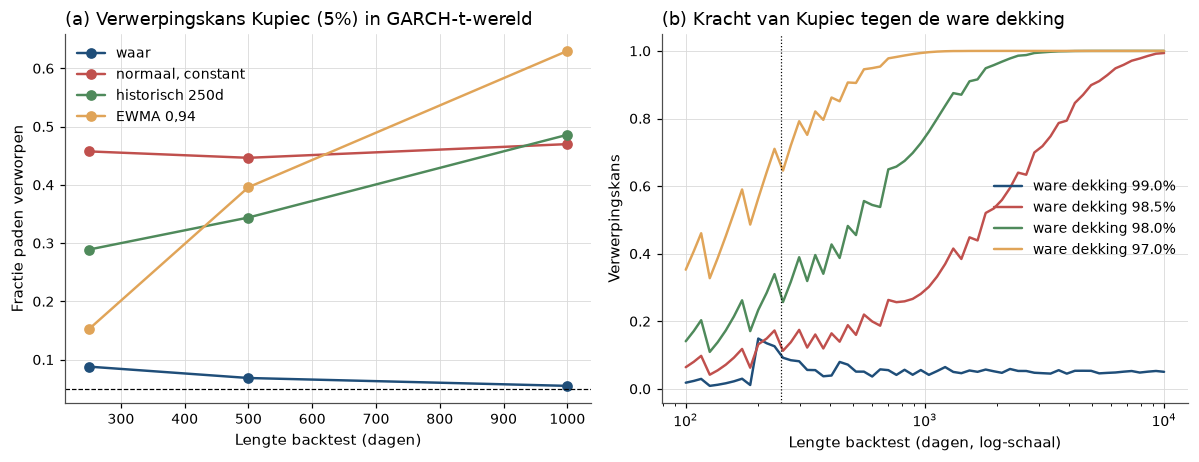

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for i, name in enumerate(hits_sim):
    rej = sim_table.loc[name, "Kupiec verwerpt"]
    axes[0].plot(rej.index, rej.values, "o-", color=hap.plotting.COLORS[i], label=name)
axes[0].axhline(0.05, color="black", lw=0.8, ls="--")
axes[0].set_title("(a) Verwerpingskans Kupiec (5%) in GARCH-t-wereld")
axes[0].set_xlabel("Lengte backtest (dagen)")
axes[0].set_ylabel("Fractie paden verworpen")
axes[0].legend()

T_grid = np.unique(np.geomspace(100, 10_000, 60).astype(int))
for i, coverage in enumerate([0.99, 0.985, 0.98, 0.97]):
    power = []
    for T in T_grid:
        x = np.arange(T + 1)
        pi_hat = x / T
        lr = -2 * ((xlogy(T - x, 0.99) + xlogy(x, 0.01)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))
        power.append(stats.binom.pmf(x, T, 1 - coverage)[lr > stats.chi2.ppf(0.95, 1)].sum())
    axes[1].plot(T_grid, power, color=hap.plotting.COLORS[i], label=f"ware dekking {coverage:.1%}")
axes[1].axvline(250, color="black", lw=0.8, ls=":")
axes[1].set_xscale("log")
axes[1].set_title("(b) Kracht van Kupiec tegen de ware dekking")
axes[1].set_xlabel("Lengte backtest (dagen, log-schaal)")
axes[1].set_ylabel("Verwerpingskans")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-risk-management-kracht
:label: fig-risk-management-kracht
:width: 100%

Links: een statisch model met de perfect gekende onvoorwaardelijke volatiliteit wordt na
een jaar in minder dan de helft van de paden verworpen, en een EWMA-model met normale
staarten, dat systematisch te weinig dekt, in een op de zeven. Rechts, exact uit de
binomiale verdeling: om een model dat 98% in plaats van 99% dekt met kans 80% te
betrappen, zijn ongeveer vier jaar dagdata nodig. De stippellijn is het ene jaar van Bazel.
:::

SIM_A_TEXT

### (b) Een convergence trade over vijf jaar

Nu het model uit [](#prop-risk-management-spiraal), op schaal. Een spreadafwijking $x_t$
(in basispunten) keert terug naar nul met $x_{t+1} = 0{,}99\,x_t + \eta_{t+1}$, waarbij
$\eta$ een normale dagschok van 1,5 basispunt is plus, gemiddeld eens in de drie jaar,
een sprong met exponentiële omvang van gemiddeld 30 basispunten; de sprongen zijn
gecompenseerd, zodat $\E[\eta] = 0$. De positie heeft duration 5 en een carry van 1% per
jaar. Ongehefboomd heeft de trade een positieve verwachte opbrengst, een lage
volatiliteit en een sterk negatieve scheefheid. Het fonds begint met $E_0 = 1$, neemt een
positie $X = LE_0$, verhoogt die elke maand weer tot $L$ maal het vermogen, en wordt
gedwongen te verkopen zodra $E < hX$ met $h = 2\%$. In de versie met fire sale verbreedt
elke gedwongen verkoop van één eenheid beginvermogen de spread met 2 basispunten; die
prijsdruk trekt daarna met dezelfde snelheid terug als de rest van de spread. We
simuleren 4000 paden van vijf jaar (1260 handelsdagen) met dezelfde schokken voor elke
hefboom, en tellen de kans op een margin call en op ruïne ($E \le 0$).

In [7]:
N_FUND, T_FUND = 4000, 1260
PHI, SIG_BP, P_JUMP, MU_JUMP, CARRY, KAPPA_FS = 0.99, 1.5, 1 / 750, 30.0, 0.01, 2.0

jump = (rng.random((T_FUND, N_FUND)) < P_JUMP) * rng.exponential(MU_JUMP, (T_FUND, N_FUND))
eta = SIG_BP * rng.standard_normal((T_FUND, N_FUND)) + jump - P_JUMP * MU_JUMP
x_spread = np.zeros((T_FUND + 1, N_FUND))
for t in range(T_FUND):
    x_spread[t + 1] = PHI * x_spread[t] + eta[t]
dx_spread = np.diff(x_spread, axis=0)
r_trade = CARRY / 252 - D * dx_spread / 1e4

sr_true = np.sqrt(252) * r_trade.mean() / r_trade.std()
sr_4y = np.sqrt(252) * r_trade[:1008].mean(axis=0) / r_trade[:1008].std(axis=0)
no_jump_4y = jump[:1008].sum(axis=0) == 0
pd.Series({"Sharpe-ratio (populatie, alle paden)": sr_true,
           "volatiliteit per jaar": np.sqrt(252) * r_trade.std(),
           "scheefheid dagrendement": stats.skew(r_trade.ravel()),
           "fractie 4-jaarsrecords zonder sprong": no_jump_4y.mean(),
           "mediane Sharpe over 4 jaar, zonder sprong": np.median(sr_4y[no_jump_4y]),
           "mediane Sharpe over 4 jaar, met sprong": np.median(sr_4y[~no_jump_4y])}).round(3)

Sharpe-ratio (populatie, alle paden)          0.584
volatiliteit per jaar                         0.017
scheefheid dagrendement                     -21.496
fractie 4-jaarsrecords zonder sprong          0.273
mediane Sharpe over 4 jaar, zonder sprong     0.880
mediane Sharpe over 4 jaar, met sprong        0.660
dtype: float64

In [8]:
def run_fund(leverage, kappa):
    """Simulate a levered convergence-trade fund with margin constraint E >= H X and fire-sale impact."""
    E = np.ones(N_FUND)
    X = leverage * E
    impact = np.zeros(N_FUND)
    alive = np.ones(N_FUND, bool)
    called = np.zeros(N_FUND, bool)
    for t in range(T_FUND):
        d_impact = (PHI - 1) * impact
        impact += d_impact
        E = np.where(alive, E + X * (CARRY / 252 - D * (dx_spread[t] + d_impact) / 1e4), E)
        for _ in range(100):                                  # forced sales until the constraint holds
            breach = alive & (X > E / H + 1e-12)
            if not breach.any():
                break
            called |= breach
            X_new = np.where(breach, np.maximum(E, 0.0) / H, X)
            widening = kappa * (X - X_new)                    # bp
            impact += widening
            E = E - X_new * D * widening / 1e4
            X = X_new
            alive &= E > 0
            X = np.where(alive, X, 0.0)
        if (t + 1) % 21 == 0:
            X = np.where(alive, leverage * E, 0.0)
    return {"P(margin call)": called.mean(), "P(ruïne)": 1 - alive.mean(),
            "mediaan eindvermogen": np.median(np.where(alive, E, 0.0))}


LEVERAGES = [1, 5, 10, 15, 20, 25, 30]
fund_no_fs = pd.DataFrame({L: run_fund(L, 0.0) for L in LEVERAGES}).T
fund_no_fs.round(3)

,P(margin call),P(ruïne),mediaan eindvermogen
1,0.000,0.000,1.052
5,0.000,0.000,1.270
10,0.009,0.002,1.573
15,0.077,0.023,1.896
20,0.210,0.061,2.232
25,0.361,0.113,2.558
30,0.500,0.168,2.846


In [9]:
fund_fs = pd.DataFrame({L: run_fund(L, KAPPA_FS) for L in LEVERAGES}).T
pd.concat({"zonder fire sale": fund_no_fs, "met fire sale": fund_fs}, axis=1).round(3)

zonder fire sale                                met fire sale           \
     P(margin call) P(ruïne) mediaan eindvermogen P(margin call) P(ruïne)   
1             0.000    0.000                1.052          0.000    0.000   
5             0.000    0.000                1.270          0.000    0.000   
10            0.009    0.002                1.573          0.009    0.002   
15            0.077    0.023                1.896          0.077    0.025   
20            0.210    0.061                2.232          0.210    0.096   
25            0.361    0.113                2.558          0.361    0.236   
30            0.500    0.168                2.846          0.500    0.397   

                         
   mediaan eindvermogen  
1                 1.052  
5                 1.270  
10                1.573  
15                1.896  
20                2.230  
25                2.520  
30                2.041

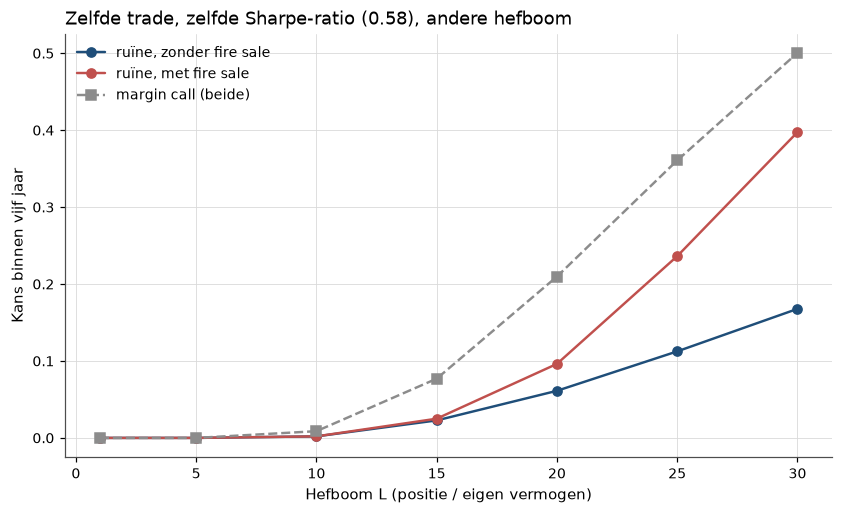

In [10]:
fig, ax = plt.subplots()
ax.plot(LEVERAGES, fund_no_fs["P(ruïne)"], "o-", color=hap.plotting.COLORS[0], label="ruïne, zonder fire sale")
ax.plot(LEVERAGES, fund_fs["P(ruïne)"], "o-", color=hap.plotting.COLORS[1], label="ruïne, met fire sale")
ax.plot(LEVERAGES, fund_no_fs["P(margin call)"], "s--", color=hap.plotting.COLORS[7], label="margin call (beide)")
ax.set_title(f"Zelfde trade, zelfde Sharpe-ratio ({sr_true:.2f}), andere hefboom")
ax.set_xlabel("Hefboom L (positie / eigen vermogen)")
ax.set_ylabel("Kans binnen vijf jaar")
ax.legend()
plt.show()

:::{figure} #cel-risk-management-ltcm-sim
:label: fig-risk-management-ltcm-sim
:width: 90%

De Sharpe-ratio van de trade is bij elke hefboom dezelfde. De kans op een margin call en op
ruïne binnen vijf jaar stijgt steil met de hefboom, en prijsdruk van de eigen gedwongen
verkopen verdubbelt de kans op ruïne boven een hefboom van ongeveer 20. Onder een hefboom
van 10 doet de fire sale er niet toe: het fonds komt de limiet niet tegen.
:::

SIM_B_TEXT

## Replicatie op echte data

### VaR-backtest 1990–2026

```{admonition} Replicatie
:class: seealso

**Bron.** J.P. Morgan/Reuters, *RiskMetrics — Technical Document*, vierde editie 1996
{cite}`JPMorganReuters1996`; Basle Committee on Banking Supervision, *Supervisory
framework for the use of "backtesting"*, 1996 {cite}`BCBS1996b`; Kupiec, *Journal of
Derivatives* 1995 {cite}`Kupiec1995`; Christoffersen, *International Economic Review*
1998 {cite}`Christoffersen1998`.

**Wat.** Tabel 2 van het Bazelse kader (zonegrenzen en cumulatieve kansen), de keuze
$\lambda = 0{,}94$ van RiskMetrics (§5.3.2.2), en de toetsen [](#eq-risk-management-kupiec)
en [](#eq-risk-management-christoffersen), toegepast op een 99%-VaR voor één dag.

**Data hier.** Kenneth French Data Library, dagelijks marktrendement (`Mkt` = `Mkt-RF` +
`RF`) 1963-07 t/m 2026-07 via `hap.data.market_daily()`; backtest 1990-01 t/m 2026-07.

**Verschil met het origineel.** Bazel toetst de handelsresultaten van een bank met
wisselende posities; wij toetsen een vaste positie in één aandelenindex. RiskMetrics
gebruikte zijn $\lambda$ op 480 reeksen, wij op één. Het GARCH-model schatten we eenmaal op
1963–1989 en gebruiken we daarna met vaste parameters, zodat de backtest niet in de
toekomst kijkt. Het papier van Kupiec geeft geen tabel die we op deze data kunnen
naleggen.

**Verwachte afwijking.** De cumulatieve kansen van tabel 2 moeten tot op 0,01 procentpunt
kloppen. Het statische normale model moet duidelijk meer dan 1% overschrijdingen hebben,
geclusterd in crisisjaren, en Christoffersen moet het verwerpen. EWMA en GARCH moeten
dichter bij 1% zitten maar erboven, omdat ze normale staarten gebruiken. Het teken van
die afwijkingen moet identiek zijn; wijkt het af, dan zit de fout in de code.
```

In [11]:
market = hap_data.market_daily()["Mkt"].loc["1963-07-01":]
z01 = stats.norm.ppf(0.01)

var_bt = pd.DataFrame(index=market.index)
var_bt["normaal, constant"] = -(market.expanding(250).mean() + z01 * market.expanding(250).std()).shift(1)
var_bt["historisch 250d"] = -market.rolling(250).quantile(0.01).shift(1)
var_bt["EWMA 0,94"] = -z01 * np.sqrt((market**2).ewm(alpha=0.06, adjust=False).mean().shift(1))

garch = arch_model(100 * market, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
garch_fit = garch.fit(last_obs="1990-01-01", disp="off")
garch_fc = garch_fit.forecast(start="1990-01-01", horizon=1, reindex=False)
var_bt["GARCH(1,1)"] = (-(garch_fit.params["mu"] + z01 * np.sqrt(garch_fc.variance["h.1"])) / 100).shift(1)

var_bt = var_bt.loc["1990-01-01":].dropna()
loss_bt = -market.loc[var_bt.index]
hits_bt = var_bt.lt(loss_bt, axis=0).astype(int)
garch_fit.params.round(4)

mu          0.0634
omega       0.0057
alpha[1]    0.0921
beta[1]     0.9047
Name: params, dtype: float64

In [12]:
full_years = hits_bt.loc[:"2025"]
by_year = full_years.groupby(full_years.index.year)
summary_bt = {}
for name in hits_bt:
    lr_ind, lr_cc = christoffersen_lr(hits_bt[name].to_numpy())
    lr_pof = kupiec_lr(hits_bt[name].to_numpy())
    yearly_counts = by_year[name].sum()
    yearly_cc = by_year[name].apply(lambda h: christoffersen_lr(h.to_numpy())[1])
    summary_bt[name] = {"dagen": len(hits_bt), "overschrijdingen": hits_bt[name].sum(),
                        "fractie (%)": 100 * hits_bt[name].mean(),
                        "LR_pof": lr_pof, "LR_ind": lr_ind, "LR_cc": lr_cc,
                        "p-waarde cc": stats.chi2.sf(lr_cc, 2),
                        "dagen met twee op rij": int((hits_bt[name] * hits_bt[name].shift(1)).sum()),
                        "jaren groen": (yearly_counts <= 4).sum(), "jaren geel": yearly_counts.between(5, 9).sum(),
                        "jaren rood": (yearly_counts >= 10).sum(),
                        "jaren cc verworpen": (yearly_cc > stats.chi2.ppf(0.95, 2)).sum()}
pd.DataFrame(summary_bt).T.round(3)

,dagen,overschrijdingen,fractie (%),LR_pof,LR_ind,LR_cc,p-waarde cc,dagen met twee op rij,jaren groen,jaren geel,jaren rood,jaren cc verworpen
"normaal, constant",9211.0,300.0,3.257,297.475,27.284,324.759,0.0,29.0,18.0,7.0,11.0,15.0
historisch 250d,9211.0,150.0,1.628,30.884,23.911,54.795,0.0,13.0,22.0,12.0,2.0,8.0
"EWMA 0,94",9211.0,182.0,1.976,69.001,6.038,75.039,0.0,9.0,16.0,18.0,2.0,7.0
"GARCH(1,1)",9211.0,198.0,2.150,92.507,4.227,96.734,0.0,9.0,15.0,20.0,1.0,10.0


In [13]:
yearly = hits_bt.groupby(hits_bt.index.year).sum()
yearly.loc[[1997, 1998, 1999, 2000, 2002, 2007, 2008, 2009, 2011, 2020, 2022]]

,"normaal, constant",historisch 250d,"EWMA 0,94","GARCH(1,1)"
date,,,,
1997,7,5,6,7
1998,16,5,7,9
1999,12,1,2,3
2000,24,7,3,4
2002,28,5,2,2
2007,10,9,10,9
2008,38,15,7,9
2009,21,0,1,5
2011,16,6,7,8


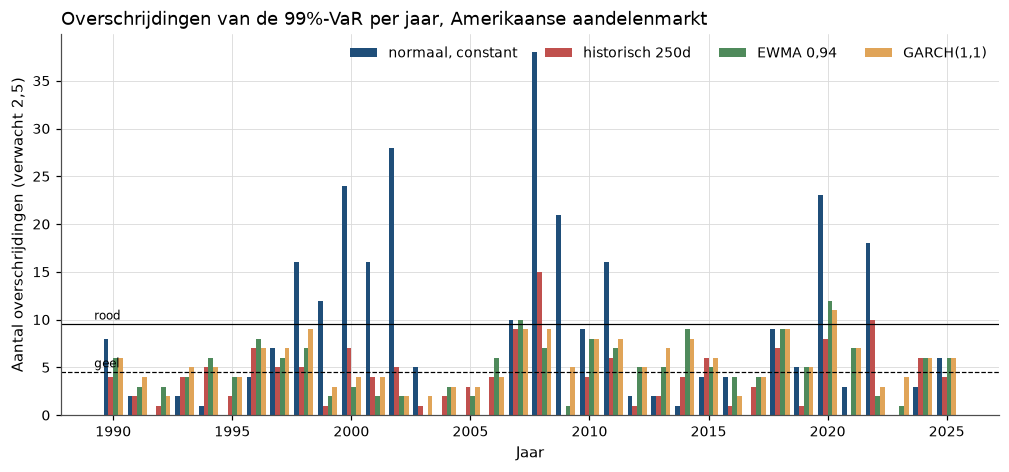

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
years = yearly.loc[:2025].index
width = 0.2
for i, name in enumerate(yearly):
    ax.bar(years + (i - 1.5) * width, yearly.loc[:2025, name], width=width, color=hap.plotting.COLORS[i], label=name)
ax.axhline(4.5, color="black", lw=0.8, ls="--")
ax.axhline(9.5, color="black", lw=0.8)
ax.text(years[0] - 0.8, 5, "geel", fontsize=8)
ax.text(years[0] - 0.8, 10, "rood", fontsize=8)
ax.set_title("Overschrijdingen van de 99%-VaR per jaar, Amerikaanse aandelenmarkt")
ax.set_xlabel("Jaar")
ax.set_ylabel("Aantal overschrijdingen (verwacht 2,5)")
ax.legend(ncol=4)
plt.show()

:::{figure} #cel-risk-management-jaren
:label: fig-risk-management-jaren
:width: 100%

Het statische normale model is rood in de jaren rond 2000 en in 2008, en haast groen in de
rustige jaren daartussen: zijn overschrijdingen komen in clusters. De drie modellen die
zich aanpassen, zitten meestal in het groene of gele gebied, maar het historische model
faalt in 2008 en EWMA en GARCH falen in 2020, toen de volatiliteit vanuit een zeer rustige
periode in enkele dagen vervijfvoudigde.
:::

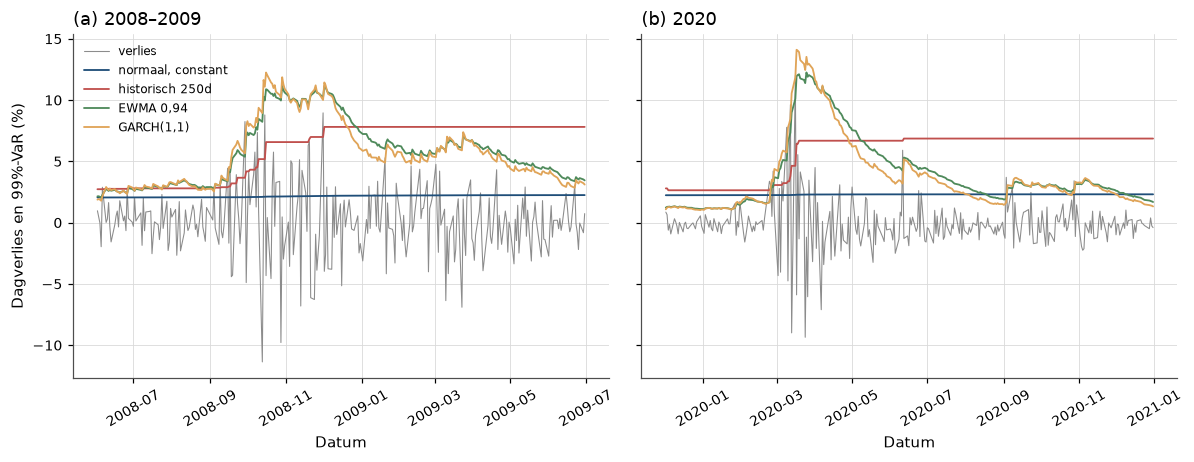

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (start_c, end_c, title) in zip(axes, [("2008-06-01", "2009-06-30", "(a) 2008–2009"),
                                              ("2019-12-01", "2020-12-31", "(b) 2020")], strict=True):
    loss_c = 100 * loss_bt.loc[start_c:end_c]
    ax.plot(loss_c.index, loss_c, color=hap.plotting.COLORS[7], lw=0.7, label="verlies")
    for i, name in enumerate(var_bt):
        ax.plot(loss_c.index, 100 * var_bt.loc[start_c:end_c, name], color=hap.plotting.COLORS[i], lw=1.2, label=name)
    ax.set_title(title)
    ax.set_xlabel("Datum")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Dagverlies en 99%-VaR (%)")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

:::{figure} #cel-risk-management-crises
:label: fig-risk-management-crises
:width: 100%

In 2008 liep de volatiliteit in weken op en EWMA en GARCH liepen mee; het historische
model reageerde pas toen de crashdagen in zijn venster zaten. In februari–maart 2020
stond de VaR van alle modellen laag toen de eerste grote verliezen kwamen.
:::

REPL_A_TEXT

### De spreads van 1998

```{admonition} Replicatie
:class: seealso

**Bron.** President's Working Group on Financial Markets, *Hedge Funds, Leverage, and the
Lessons of Long-Term Capital Management*, april 1999 {cite}`PresidentsWorkingGroup1999`;
Jorion, *European Financial Management* 2000 {cite}`Jorion2000`.

**Wat.** De beschrijving op p. 12 en 16 van het rapport: na de Russische
devaluatie en het moratorium van 17 augustus 1998 "risk spreads and liquidity premiums
rose sharply in markets around the world", terwijl LTCM "was betting in general that
liquidity, credit and volatility spreads would narrow from historically high levels".

**Data hier.** FRED, dagelijks: `BAA10Y` en `AAA10Y` (Moody's Baa- en Aaa-bedrijfsobligaties
min de tienjaars staatsrente), `TEDRATE` (driemaands Eurodollar-rente min driemaands
T-bill) en `DGS10`, via `hap.data.fred(...)`.

**Verschil met het origineel.** De posities van LTCM zijn niet publiek; we tonen alleen
dat het soort spreads waarop het fonds wedde, verbreedde. De swap spreads die voor LTCM
het belangrijkst waren, staan niet gratis in FRED voor 1998 (de reeks `DSWP10` begint in
juli 2000). Obligatierendementen van Moody's zijn gemiddelden over looptijden en geen
handelbare spread.

**Verwachte afwijking.** Alle drie de spreads moeten tussen half augustus en half oktober
1998 met tientallen basispunten verbreden, veel meer dan de dagelijkse schommelingen van
1997 over die periode doen verwachten, terwijl de tienjaars staatsrente daalt (een vlucht
naar kwaliteit). Het teken van elke beweging moet kloppen.
```

In [16]:
spreads = pd.concat([hap_data.fred(s)[s] for s in ["BAA10Y", "AAA10Y", "TEDRATE", "DGS10"]], axis=1, sort=True)
spreads = spreads.loc["1997-01-01":"1999-12-31"].dropna()
before = spreads.loc[:"1998-08-14"].iloc[-1]
crisis = spreads.loc["1998-08-17":"1998-10-31"]
extreme = pd.concat([crisis[["BAA10Y", "AAA10Y", "TEDRATE"]].max(), crisis[["DGS10"]].min()])
extreme_date = pd.concat([crisis[["BAA10Y", "AAA10Y", "TEDRATE"]].idxmax(), crisis[["DGS10"]].idxmin()])
n_days_move = pd.Series({s: len(spreads.loc["1998-08-15":extreme_date[s]]) for s in spreads})
sd_1997 = spreads.loc["1997"].diff().std()
pd.DataFrame({"14 aug 1998 (%)": before, "extreem aug-okt (%)": extreme, "datum": extreme_date.dt.date,
              "verandering (bp)": 100 * (extreme - before),
              "SD dagverandering 1997 (bp)": 100 * sd_1997,
              "in SD's (sqrt-tijd)": (extreme - before) / (sd_1997 * np.sqrt(n_days_move))}).round(2)

,14 aug 1998 (%),extreem aug-okt (%),datum,verandering (bp),SD dagverandering 1997 (bp),in SD's (sqrt-tijd)
BAA10Y,1.74,2.77,1998-10-16,103.0,2.39,6.64
AAA10Y,1.12,1.96,1998-10-16,84.0,1.98,6.55
TEDRATE,0.79,1.66,1998-10-16,87.0,4.57,2.94
DGS10,5.40,4.16,1998-10-05,-124.0,4.92,-4.32


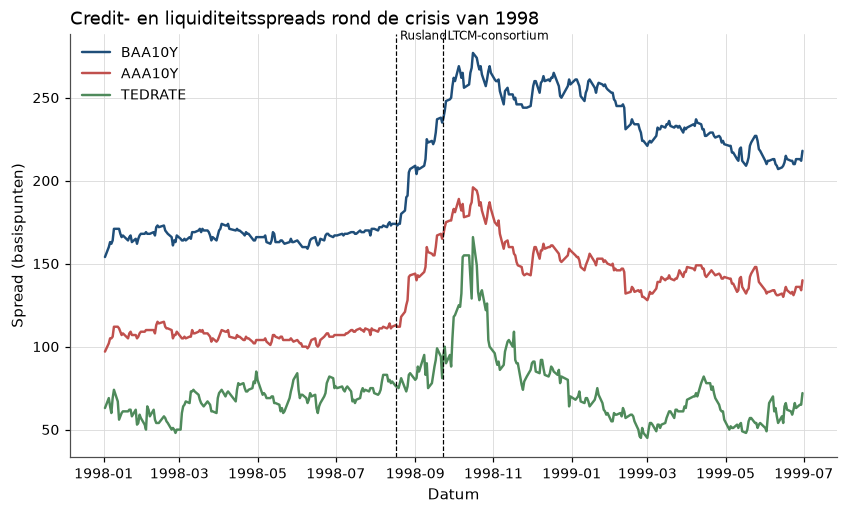

In [17]:
fig, ax = plt.subplots()
window = spreads.loc["1998-01-01":"1999-06-30"]
for i, s in enumerate(["BAA10Y", "AAA10Y", "TEDRATE"]):
    ax.plot(window.index, 100 * window[s], color=hap.plotting.COLORS[i], label=s)
for date, text in [("1998-08-17", "Rusland"), ("1998-09-23", "LTCM-consortium")]:
    ax.axvline(pd.Timestamp(date), color="black", lw=0.8, ls="--")
    ax.text(pd.Timestamp(date), 285, f" {text}", fontsize=8)
ax.set_title("Credit- en liquiditeitsspreads rond de crisis van 1998")
ax.set_xlabel("Datum")
ax.set_ylabel("Spread (basispunten)")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-risk-management-spreads
:label: fig-risk-management-spreads
:width: 90%

Na 17 augustus verbreedden bedrijfsobligatiespreads en de TED-spread in enkele weken met
meer dan tachtig basispunten, en de piek viel pas in oktober, na de redding van LTCM. De
bedrijfsobligatiespreads waren begin 1999 nog niet terug op hun niveau van juli 1998.
:::

REPL_B_TEXT

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** VaR gaf risicobeheer een gemeenschappelijke taal en een
getal waarop je limieten, kapitaal en bonussen kunt baseren. Het gebruikt precies wat de
vorige lecture meetbaar maakte, het tweede moment, en laat weg wat niet meetbaar is, het
gemiddelde. Het werkt redelijk: in onze backtest liggen de modellen die zich aanpassen
een factor twee boven de 1%, tegen een factor drie voor een statisch model, en ze zitten
in de meeste jaren in het groene of gele gebied. De backtests van Kupiec en Christoffersen
maakten het mogelijk om een risicomodel te weerleggen, wat eerder niet kon, en de
coherentie-axioma's gaven de discussie over wat een risicomaat moet doen een wiskundige
vorm die in 2016 in de regels belandde.

**Waar het breekt.** Het breekt waar het getal niets over zegt. Een 99%-VaR die in 2020
twaalf keer wordt overschreden, is geen goed model dat pech had. De spreads waarop LTCM
wedde, bewogen in twee maanden vijf tot acht keer zoveel standaarddeviaties als de
dagelijkse schommelingen van het jaar ervoor voorspelden, en daar horen kansen bij die
een normaal model onmogelijk noemt. Het rapport van de President's Working Group schreef
dat de verliezen "greatly exceeded what conventional risk models, estimated during more
stable periods, suggested were probable" (p. 12). Santa-Clara: LTCM en "the whole dealer
system in 2008 had risk departments, models and limits, and were destroyed by losses their
models had called impossible" {cite}`SantaClara2026`. Het echte gebrek was niet het
kwantiel maar de aanname dat de positie tegen de marktprijs kon worden gesloten. Onze
simulatie laat zien dat een fonds met dezelfde Sharpe-ratio een kans op ruïne van bijna
nul of van een op vier heeft, afhankelijk van de hefboom en van de vraag of het de markt
zelf beweegt.

**Risico of vergissing?** De Chicago-lezing: de spreads van 1997 waren een beloning voor
het dragen van liquiditeits- en crashrisico, en augustus 1998 was de slechte toestand
waarvoor die beloning betaald werd. LTCM droeg een beprijsd risico, maar met te weinig
kapitaal; dat een fonds met hefboom 25 zo'n toestand niet overleeft, bewijst niet dat de
prijzen verkeerd waren. Dat de spreads begin 1999 voor een deel terugliepen, past bij
beide lezingen. De Yale-lezing, van {cite:t}`ShleiferVishny1997`: de spreads werden groter
dan hun fundamentele waarde *omdat* de arbitrageurs moesten verkopen; de mispricing was
op haar grootst toen niemand er meer tegenin kon gaan, en LTCM dacht iets te weten wat de
prijs niet wist. Welke data zou de lezingen scheiden? De posities en verkopen van de
arbitrageurs zelf, gekoppeld aan hoe snel de spreads na hun verkopen terugliepen. Die
data is voor 1998 niet publiek, en één episode is geen steekproef. Het praktijkmotief van
Santa-Clara geeft hier geen uitsluitsel over de prijzen, alleen over het fonds: het
rendement kwam uit beprijsd risico, het verlies uit de overtuiging dat de hefboom veilig
was.

**Wat er daarna kwam.** Als rationele arbitrageurs een mispricing niet kunnen wegwerken
omdat hun financiering verdwijnt, ligt de vraag voor de hand wie die prijzen dan zet en
waarom beleggers ervan afwijken: [behavioral finance en limits of arbitrage](#04-23-behavioral).

## Oefeningen

:::{exercise}
:label: ex-risk-management-1

**ES en VaR bij dikke staarten.** Laat $L = \sigma T_\nu\sqrt{(\nu-2)/\nu}$ met $T_\nu$
Student-$t$ met $\nu > 2$ vrijheidsgraden, zodat $\SD(L) = \sigma$.

1. Laat zien dat $\mathrm{ES}_\alpha(T_\nu) = \dfrac{f_\nu(t_\alpha)}{1-\alpha}\cdot\dfrac{\nu + t_\alpha^2}{\nu-1}$,
   met $f_\nu$ de dichtheid en $t_\alpha$ het $\alpha$-kwantiel van $T_\nu$.
2. Bereken voor $\nu \in \{4, 6, 10, \infty\}$ de verhouding
   $\mathrm{ES}_{0{,}975}/\mathrm{VaR}_{0{,}99}$ van $L$.
3. Wat betekent dat voor het kapitaal onder de regels van 2016 ten opzichte van die van
   1996, bij een gelijke volatiliteit?
:::

:::{solution} ex-risk-management-1
:class: dropdown

**(1)** Voor de $t$-dichtheid geldt $\frac{\mathrm{d}}{\mathrm{d}t}\left[\frac{\nu+t^2}{\nu-1}f_\nu(t)\right] = -t f_\nu(t)$,
wat je nagaat door $f_\nu(t) \propto (1+t^2/\nu)^{-(\nu+1)/2}$ te differentiëren. Dus
$\int_{t_\alpha}^\infty t f_\nu(t)\,\mathrm{d}t = \frac{\nu+t_\alpha^2}{\nu-1}f_\nu(t_\alpha)$;
deel door $1-\alpha$. Voor $\nu \to \infty$ is dit $\varphi(z_\alpha)/(1-\alpha)$ uit
[](#eq-risk-management-normaal).

In [18]:
def t_scaled(alpha, nu):
    """Standardised (unit variance) Student-t VaR and ES at level alpha."""
    if np.isinf(nu):
        z = stats.norm.ppf(alpha)
        return z, stats.norm.pdf(z) / (1 - alpha)
    q = stats.t.ppf(alpha, nu)
    es = stats.t.pdf(q, nu) / (1 - alpha) * (nu + q**2) / (nu - 1)
    scale = np.sqrt((nu - 2) / nu)
    return q * scale, es * scale


es_check = stats.t.expect(lambda x: x, args=(6,), lb=stats.t.ppf(0.975, 6)) / 0.025
print(f"controle nu = 6: formule {t_scaled(0.975, 6)[1] / np.sqrt(4 / 6):.4f}, numeriek {es_check:.4f}")
pd.DataFrame({nu: {"VaR 99%": t_scaled(0.99, nu)[0], "ES 97,5%": t_scaled(0.975, nu)[1],
                   "ES 97,5% / VaR 99%": t_scaled(0.975, nu)[1] / t_scaled(0.99, nu)[0]}
              for nu in (4, 6, 10, np.inf)}).T.round(3)

controle nu = 6: formule 3.2562, numeriek 3.2562


,VaR 99%,"ES 97,5%","ES 97,5% / VaR 99%"
4.0,2.649,2.824,1.066
6.0,2.566,2.659,1.036
10.0,2.472,2.521,1.020
inf,2.326,2.338,1.005


Bij normale verdelingen is de verhouding 1,005, bij $\nu = 6$ ongeveer 1,05 en bij
$\nu = 4$ ongeveer 1,07; bij een gelijke volatiliteit is de gestandaardiseerde
$t$-VaR op 99% juist lager dan de normale, maar de ES stijgt. De overstap op ES laat het
kapitaal onder normaliteit gelijk en maakt dikke staarten relatief duurder, wat precies
de zwakte van VaR is die Santa-Clara noemt. (Daarnaast verhoogt de kalibratie op een
stressperiode het kapitaal in de regels van 2016; dat zit niet in deze oefening.)
:::

:::{exercise}
:label: ex-risk-management-2

**Tabel 1 van Bazel en de kracht van de verkeerslichten.**

1. Bereken voor een backtest van 250 dagen de kans dat een model met ware dekking 98%, 97%
   en 95% in het groene gebied valt. Vergelijk met de "type 2"-kolom bij vijf
   overschrijdingen in tabel 1 van het Bazelse kader: 43,9%, 12,8% en 0,5%.
2. Hoeveel dagen backtest zijn nodig voordat Kupiec's toets op 5% een model met ware
   dekking 98% in minstens 80% van de gevallen verwerpt?
3. Vertaal (2) naar jaren en koppel het aan motief 1.
:::

:::{solution} ex-risk-management-2
:class: dropdown

In [19]:
green = {c: stats.binom.cdf(4, 250, 1 - c) for c in (0.98, 0.97, 0.95)}
print("P(groen):", {k: round(v, 3) for k, v in green.items()})


def kupiec_power(T, coverage, level=0.05):
    """Exact power of the Kupiec POF test against a model with the given true coverage."""
    x = np.arange(T + 1)
    pi_hat = x / T
    lr = -2 * ((xlogy(T - x, 0.99) + xlogy(x, 0.01)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))
    return stats.binom.pmf(x, T, 1 - coverage)[lr > stats.chi2.ppf(1 - level, 1)].sum()


T_needed = next(T for T in range(250, 5000, 10) if kupiec_power(T, 0.98) >= 0.80)
print(f"dagen nodig voor 80% kracht tegen 98% dekking: {T_needed} (= {T_needed / 250:.1f} jaar)")

P(groen): {0.98: np.float64(0.439), 0.97: np.float64(0.128), 0.95: np.float64(0.005)}
dagen nodig voor 80% kracht tegen 98% dekking: 1070 (= 4.3 jaar)


De kansen op groen zijn 43,9%, 12,8% en 0,5%, precies tabel 1 van het kader. Om een model
dat twee keer zo vaak faalt als het hoort met 80% kans te betrappen, zijn ongeveer vier
jaar dagdata nodig; omdat de kracht door de discrete verdeling niet monotoon stijgt, kan
het precieze getal met een paar dagen verschuiven. Een zeldzame gebeurtenis meten is als
een gemiddeld rendement meten: de standaardfout daalt met $1/\sqrt{T}$, en de grootheid
zelf is klein.
:::

:::{exercise}
:label: ex-risk-management-3

**Filtered historical simulation.** Voeg aan de backtest van 1990–2026 twee modellen toe:
(i) GARCH(1,1) met gestandaardiseerde Student-$t$-schokken, geschat op 1963–1989; (ii)
filtered historical simulation: deel de rendementen door de EWMA-volatiliteit
($\lambda = 0{,}94$), neem het empirische 1%-kwantiel van de gestandaardiseerde
rendementen over de voorgaande 1000 dagen, en vermenigvuldig met de EWMA-volatiliteit van
morgen. Rapporteer het totaal aantal overschrijdingen, de jaren in het rode gebied en het
aantal in 1998, 2008 en 2020. Welk probleem lost elk model op?
:::

:::{solution} ex-risk-management-3
:class: dropdown

In [20]:
garch_t = arch_model(100 * market, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
garch_t_fit = garch_t.fit(last_obs="1990-01-01", disp="off")
nu_hat = garch_t_fit.params["nu"]
q01_t = stats.t.ppf(0.01, nu_hat) * np.sqrt((nu_hat - 2) / nu_hat)
fc_t = garch_t_fit.forecast(start="1990-01-01", horizon=1, reindex=False)
var_garch_t = (-(garch_t_fit.params["mu"] + q01_t * np.sqrt(fc_t.variance["h.1"])) / 100).shift(1)

ewma_sd = np.sqrt((market**2).ewm(alpha=0.06, adjust=False).mean())
standardised = market / ewma_sd.shift(1)
var_fhs = -(standardised.rolling(1000).quantile(0.01) * ewma_sd).shift(1)

extra = pd.DataFrame({"GARCH-t": var_garch_t, "FHS (EWMA)": var_fhs}).reindex(var_bt.index)
hits_extra = extra.lt(loss_bt, axis=0).astype(int)
yearly_extra = hits_extra.groupby(hits_extra.index.year).sum()
pd.DataFrame({name: {"nu": nu_hat if name == "GARCH-t" else np.nan,
                     "overschrijdingen": hits_extra[name].sum(),
                     "fractie (%)": 100 * hits_extra[name].mean(),
                     "jaren rood (t/m 2025)": (yearly_extra.loc[:2025, name] >= 10).sum(),
                     "1998": yearly_extra.loc[1998, name], "2008": yearly_extra.loc[2008, name],
                     "2020": yearly_extra.loc[2020, name]} for name in extra}).T.round(3)

,nu,overschrijdingen,fractie (%),jaren rood (t/m 2025),1998,2008,2020
GARCH-t,7.446,156.0,1.694,1.0,6.0,6.0,10.0
FHS (EWMA),NaN,107.0,1.162,0.0,5.0,4.0,4.0


EX3_TEXT
:::

:::{exercise}
:label: ex-risk-management-4

**Een marginspiraal.** Maak in toy-voorbeeld (c) de haircut afhankelijk van de
spreadverbreding: $h(\Delta s) = h_0 + \eta\,\Delta s$, met $h_0 = 2\%$ en $\eta = 10$
(een procentpunt extra haircut per tien basispunten verbreding), zoals bij
{cite:t}`BrunnermeierPedersen2009` waar marges met de volatiliteit stijgen.

1. Leid af bij welke verbreding de margin call komt voor een fonds met $E_0 = 100$,
   $L = 25$ en $D = 5$ dat zijn positie vasthoudt.
2. Controleer het getal numeriek en vergelijk met de 40 basispunten zonder stijgende
   haircut.
:::

:::{solution} ex-risk-management-4
:class: dropdown

**(1)** De margin call komt als $E_0 - XD\Delta s = (h_0 + \eta\Delta s)X$, dus
$\Delta s^{\mathrm{call}} = (E_0 - h_0X)/(X(D + \eta))$. Met $X = 2500$ is dat
$50/(2500 \times 15) = 13{,}3$ basispunten.

In [21]:
def margin_surplus(ds, eta, E0=100.0, X=2500.0, D=5.0, h0=0.02):
    """Equity minus required margin after a spread widening ds (decimal) with haircut h0 + eta * ds."""
    return (E0 - X * D * ds) - (h0 + eta * ds) * X


grid = np.linspace(0, 0.01, 100_001)          # 0 to 100 bp in steps of 0.001 bp
for eta in (0.0, 10.0):
    ds_star = grid[np.argmax(margin_surplus(grid, eta) < 0)]
    print(f"eta = {eta:4.1f}: margin call bij {1e4 * ds_star:.1f} bp, "
          f"formule {1e4 * 50 / (2500 * (5 + eta)):.1f} bp")

eta =  0.0: margin call bij 40.0 bp, formule 40.0 bp
eta = 10.0: margin call bij 13.3 bp, formule 13.3 bp


Een stijgende haircut verlaagt de drempel van 40 naar 13,3 basispunten: een derde. De
hefboom die de tegenpartij toestaat, verdwijnt op het moment dat het fonds haar nodig
heeft. Dat is les negen van Santa-Clara in één vergelijking.
:::